In [1]:
# Cell 1 — Import Libraries

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Cell 2 — Load Dataset

file_path = r"C:\Users\bts\OneDrive\Desktop\SaiKet Systems\dataset\Telco_Customer_Churn_Dataset.csv"

if not os.path.exists(file_path):
    alternative_path = "Telco_Customer_Churn_Dataset(1).csv"
    if os.path.exists(alternative_path):
        file_path = alternative_path
    else:
        raise FileNotFoundError(
            "Dataset not found. Place Telco_Customer_Churn_Dataset.csv "
            "in the same folder as this notebook."
        )

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cell 3 — Data Inspection

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset shape:", df.shape)


Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender       

In [4]:
# Cell 4 — Data Cleaning

df = df.copy()

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = df["TotalCharges"].isna().sum()

df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df = df.drop(columns=["customerID"])

print("Invalid TotalCharges rows removed:", invalid_total_charges)
print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())


Invalid TotalCharges rows removed: 11
Cleaned dataset shape: (7032, 20)
Remaining missing values: 0


In [5]:
# Cell 5 — Overall Business Baseline

total_customers = len(df)
churned_customers = int(df["Churn"].sum())
retained_customers = total_customers - churned_customers

current_churn_rate = df["Churn"].mean()
current_retention_rate = 1 - current_churn_rate

total_monthly_revenue = df["MonthlyCharges"].sum()
average_monthly_charge = df["MonthlyCharges"].mean()

total_customer_revenue = df["TotalCharges"].sum()
average_customer_revenue = df["TotalCharges"].mean()

business_baseline = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Current Churn Rate",
        "Current Retention Rate",
        "Total Monthly Revenue",
        "Average Monthly Charge",
        "Total Customer Revenue",
        "Average Customer Revenue"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        current_churn_rate,
        current_retention_rate,
        total_monthly_revenue,
        average_monthly_charge,
        total_customer_revenue,
        average_customer_revenue
    ]
})

business_baseline


,Metric,Value
0,Total Customers,7.032000e+03
1,Churned Customers,1.869000e+03
2,Retained Customers,5.163000e+03
3,Current Churn Rate,2.657850e-01
4,Current Retention Rate,7.342150e-01
5,Total Monthly Revenue,4.556610e+05
6,Average Monthly Charge,6.479821e+01
7,Total Customer Revenue,1.605617e+07
8,Average Customer Revenue,2.283300e+03


In [6]:
# Cell 6 — Churn Analysis by Contract

contract_analysis = (
    df.groupby("Contract")
      .agg(
          Customers=("Churn", "size"),
          Churned_Customers=("Churn", "sum"),
          Churn_Rate=("Churn", "mean"),
          Average_Monthly_Charge=("MonthlyCharges", "mean"),
          Monthly_Revenue=("MonthlyCharges", "sum")
      )
      .reset_index()
      .sort_values("Churn_Rate", ascending=False)
)

contract_analysis


,Contract,Customers,Churned_Customers,Churn_Rate,Average_Monthly_Charge,Monthly_Revenue
0,Month-to-month,3875,1655,0.427097,66.398490,257294.15
1,One year,1472,166,0.112772,65.079416,95796.90
2,Two year,1685,48,0.028487,60.872374,102569.95


In [7]:
# Cell 7 — Churn Analysis by Tenure

df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72, np.inf],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months",
        "73+ Months"
    ]
)

tenure_analysis = (
    df.groupby("Tenure_Group", observed=False)
      .agg(
          Customers=("Churn", "size"),
          Churned_Customers=("Churn", "sum"),
          Churn_Rate=("Churn", "mean"),
          Average_Monthly_Charge=("MonthlyCharges", "mean"),
          Monthly_Revenue=("MonthlyCharges", "sum")
      )
      .reset_index()
)

tenure_analysis


,Tenure_Group,Customers,Churned_Customers,Churn_Rate,Average_Monthly_Charge,Monthly_Revenue
0,0-6 Months,1470,784,0.533333,54.838333,80612.35
1,7-12 Months,705,253,0.358865,58.952908,41561.80
2,13-24 Months,1024,294,0.287109,61.357275,62829.85
3,25-48 Months,1594,325,0.203890,65.930552,105093.30
4,49-72 Months,2239,213,0.095132,73.945377,165563.70
5,73+ Months,0,0,NaN,NaN,0.00


In [8]:
# Cell 8 — Churn Analysis by Internet Service

internet_analysis = (
    df.groupby("InternetService")
      .agg(
          Customers=("Churn", "size"),
          Churned_Customers=("Churn", "sum"),
          Churn_Rate=("Churn", "mean"),
          Average_Monthly_Charge=("MonthlyCharges", "mean"),
          Monthly_Revenue=("MonthlyCharges", "sum")
      )
      .reset_index()
      .sort_values("Churn_Rate", ascending=False)
)

internet_analysis


,InternetService,Customers,Churned_Customers,Churn_Rate,Average_Monthly_Charge,Monthly_Revenue
1,Fiber optic,3096,1297,0.418928,91.500129,283284.40
0,DSL,2416,459,0.189983,58.088017,140340.65
2,No,1520,113,0.074342,21.076283,32035.95


In [9]:
# Cell 9 — Churn Analysis by Payment Method

payment_analysis = (
    df.groupby("PaymentMethod")
      .agg(
          Customers=("Churn", "size"),
          Churned_Customers=("Churn", "sum"),
          Churn_Rate=("Churn", "mean"),
          Average_Monthly_Charge=("MonthlyCharges", "mean"),
          Monthly_Revenue=("MonthlyCharges", "sum")
      )
      .reset_index()
      .sort_values("Churn_Rate", ascending=False)
)

payment_analysis


,PaymentMethod,Customers,Churned_Customers,Churn_Rate,Average_Monthly_Charge,Monthly_Revenue
2,Electronic check,2365,1071,0.452854,76.255814,180345.0
3,Mailed check,1604,308,0.192020,43.958354,70509.2
0,Bank transfer (automatic),1542,258,0.167315,67.205577,103631.0
1,Credit card (automatic),1521,232,0.152531,66.519264,101175.8


In [10]:
# Cell 10 — Churn Analysis by Senior Citizen Status

senior_analysis = (
    df.groupby("SeniorCitizen")
      .agg(
          Customers=("Churn", "size"),
          Churned_Customers=("Churn", "sum"),
          Churn_Rate=("Churn", "mean"),
          Average_Monthly_Charge=("MonthlyCharges", "mean"),
          Monthly_Revenue=("MonthlyCharges", "sum")
      )
      .reset_index()
)

senior_analysis["Customer_Type"] = senior_analysis["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

senior_analysis


,SeniorCitizen,Customers,Churned_Customers,Churn_Rate,Average_Monthly_Charge,Monthly_Revenue,Customer_Type
0,0,5890,1393,0.236503,61.885594,364506.15,Non-Senior
1,1,1142,476,0.416813,79.820359,91154.85,Senior


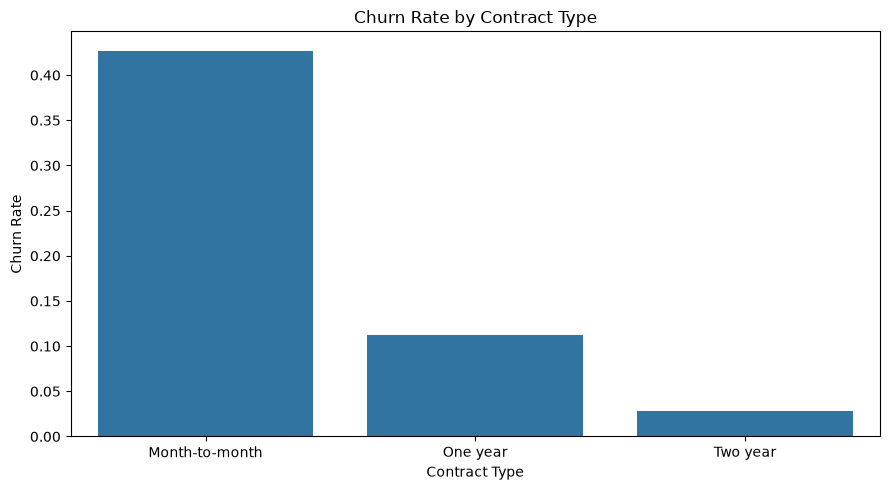

In [11]:
# Cell 11 — Visualize Churn by Contract

plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_analysis,
    x="Contract",
    y="Churn_Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()


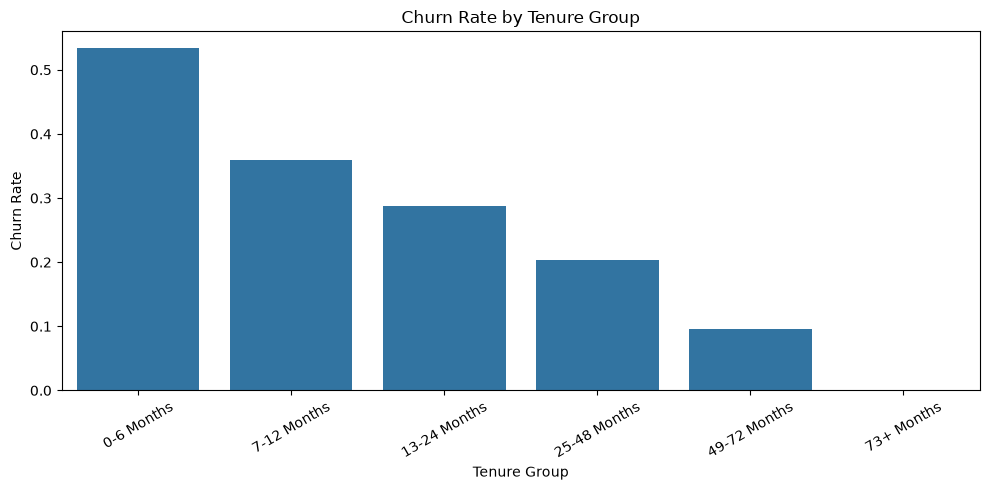

In [12]:
# Cell 12 — Visualize Churn by Tenure

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_analysis,
    x="Tenure_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [13]:
# Cell 13 — Prepare Predictive Modeling Data

model_df = df.drop(columns=["Tenure_Group"]).copy()

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Training rows: 5625
Testing rows: 1407
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [14]:
# Cell 14 — Create Preprocessing Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


In [15]:
# Cell 15 — Train and Tune Candidate Models

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000),
        {"model__C": [0.1, 1, 10]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_split": [2, 10, 20]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        {
            "model__max_depth": [None, 10],
            "model__min_samples_split": [2, 5]
        }
    )
}

model_results = []
best_estimators = {}

for model_name, (model, param_grid) in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_estimators[model_name] = grid_search.best_estimator_

    test_pred = grid_search.predict(X_test)
    test_prob = grid_search.predict_proba(X_test)[:, 1]

    model_results.append({
        "Model": model_name,
        "CV_Best_F1": grid_search.best_score_,
        "Test_Accuracy": accuracy_score(y_test, test_pred),
        "Test_Precision": precision_score(y_test, test_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, test_pred, zero_division=0),
        "Test_F1": f1_score(y_test, test_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, test_prob),
        "Best_Parameters": str(grid_search.best_params_)
    })

model_comparison = pd.DataFrame(model_results).sort_values(
    "CV_Best_F1",
    ascending=False
).reset_index(drop=True)

model_comparison


,Model,CV_Best_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Best_Parameters
0,Logistic Regression,0.596455,0.800284,0.639640,0.569519,0.602546,0.835088,{'model__C': 10}
1,Random Forest,0.583934,0.791756,0.633663,0.513369,0.567208,0.831627,"{'model__max_depth': 10, 'model__min_samples_s..."
2,Decision Tree,0.573982,0.789623,0.602094,0.614973,0.608466,0.829625,"{'model__max_depth': 5, 'model__min_samples_sp..."


In [16]:
# Cell 16 — Select Best Model

best_model_name = model_comparison.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

print("Best model:", best_model_name)
print("Selection criterion: highest 5-fold cross-validated F1-score")
print("CV Best F1:", round(model_comparison.iloc[0]["CV_Best_F1"], 4))


Best model: Logistic Regression
Selection criterion: highest 5-fold cross-validated F1-score
CV Best F1: 0.5965


In [17]:
# Cell 17 — Final Model Evaluation

test_predictions = best_model.predict(X_test)
test_probabilities = best_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, test_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_probabilities)
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.800284,0.63964,0.569519,0.602546,0.835088


In [18]:
# Cell 18 — Score the Full Customer Base

# Fit the selected model on all available cleaned customer records.
full_model = best_estimators[best_model_name]
full_model.fit(X, y)

all_churn_probabilities = full_model.predict_proba(X)[:, 1]

customer_risk = df.copy()

customer_risk["Churn_Probability"] = all_churn_probabilities

customer_risk["Risk_Level"] = pd.cut(
    customer_risk["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Customer risk scoring completed.")
customer_risk[["Churn_Probability", "Risk_Level"]].head()


Customer risk scoring completed.


,Churn_Probability,Risk_Level
0,0.641165,High Risk
1,0.042939,Low Risk
2,0.290825,Low Risk
3,0.030260,Low Risk
4,0.698473,High Risk


In [19]:
# Cell 19 — Customer Risk Summary

risk_summary = (
    customer_risk.groupby("Risk_Level", observed=False)
    .agg(
        Customers=("Churn", "size"),
        Actual_Churned=("Churn", "sum"),
        Average_Churn_Probability=("Churn_Probability", "mean"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Monthly_Revenue=("MonthlyCharges", "sum")
    )
    .reset_index()
)

risk_summary["Actual_Churn_Rate"] = (
    risk_summary["Actual_Churned"] /
    risk_summary["Customers"]
)

risk_summary["Annual_Revenue_Exposure"] = (
    risk_summary["Monthly_Revenue"] * 12
)

risk_summary


,Risk_Level,Customers,Actual_Churned,Average_Churn_Probability,Average_Monthly_Charge,Monthly_Revenue,Actual_Churn_Rate,Annual_Revenue_Exposure
0,Low Risk,4367,423,0.097073,57.564117,251382.50,0.096863,3016590.0
1,Medium Risk,1646,713,0.448639,73.665340,121253.15,0.433171,1455037.8
2,High Risk,1019,733,0.693614,81.477282,83025.35,0.719333,996304.2


In [20]:
# Cell 20 — Identify Priority Customer Segments

segment_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "SeniorCitizen"
]

segment_results = []

for column in segment_columns:

    grouped = (
        customer_risk.groupby(column)
        .agg(
            Customers=("Churn", "size"),
            Actual_Churns=("Churn", "sum"),
            Churn_Rate=("Churn", "mean"),
            Average_Churn_Probability=("Churn_Probability", "mean"),
            Monthly_Revenue=("MonthlyCharges", "sum"),
            Average_Monthly_Charge=("MonthlyCharges", "mean")
        )
        .reset_index()
    )

    grouped["Segment_Type"] = column
    grouped = grouped.rename(columns={column: "Segment_Value"})

    segment_results.append(grouped)

segment_analysis = pd.concat(
    segment_results,
    ignore_index=True
)

segment_analysis["Annual_Revenue_Exposure"] = (
    segment_analysis["Monthly_Revenue"] * 12
)

segment_analysis["Priority_Score"] = (
    segment_analysis["Churn_Rate"] *
    segment_analysis["Annual_Revenue_Exposure"]
)

priority_segments = segment_analysis.sort_values(
    "Priority_Score",
    ascending=False
).reset_index(drop=True)

priority_segments.head(15)


,Segment_Value,Customers,Actual_Churns,Churn_Rate,Average_Churn_Probability,Monthly_Revenue,Average_Monthly_Charge,Segment_Type,Annual_Revenue_Exposure,Priority_Score
0,Fiber optic,3096,1297,0.418928,0.418858,283284.40,91.500129,InternetService,3399412.8,1.424108e+06
1,Month-to-month,3875,1655,0.427097,0.427075,257294.15,66.398490,Contract,3087529.8,1.318674e+06
2,0,5890,1393,0.236503,0.236534,364506.15,61.885594,SeniorCitizen,4374073.8,1.034480e+06
3,Electronic check,2365,1071,0.452854,0.452827,180345.00,76.255814,PaymentMethod,2164140.0,9.800397e+05
4,1,1142,476,0.416813,0.416801,91154.85,79.820359,SeniorCitizen,1093858.2,4.559339e+05
5,DSL,2416,459,0.189983,0.190034,140340.65,58.088017,InternetService,1684087.8,3.199488e+05
6,Bank transfer (automatic),1542,258,0.167315,0.167312,103631.00,67.205577,PaymentMethod,1243572.0,2.080685e+05
7,Credit card (automatic),1521,232,0.152531,0.152490,101175.80,66.519264,PaymentMethod,1214109.6,1.851896e+05
8,Mailed check,1604,308,0.192020,0.192209,70509.20,43.958354,PaymentMethod,846110.4,1.624701e+05
9,One year,1472,166,0.112772,0.112748,95796.90,65.079416,Contract,1149562.8,1.296382e+05


In [21]:
# Cell 21 — Generate Data-Driven Recommendations

highest_contract = contract_analysis.iloc[0]
highest_tenure = tenure_analysis.loc[
    tenure_analysis["Churn_Rate"].idxmax()
]
highest_internet = internet_analysis.iloc[0]
highest_payment = payment_analysis.iloc[0]
highest_priority_segment = priority_segments.iloc[0]

recommendations = pd.DataFrame({
    "Priority": [
        1,
        2,
        3,
        4,
        5
    ],
    "Recommendation": [
        "Use predictive churn scoring for proactive retention outreach.",
        "Prioritize segments with high churn and meaningful revenue exposure.",
        "Design contract-focused retention offers for high-churn contract groups.",
        "Use early-lifecycle onboarding and engagement for high-churn tenure groups.",
        "Review service and payment experience in segments with elevated observed churn."
    ],
    "Data_Driven_Basis": [
        f"Model selected: {best_model_name}; high-risk customers are explicitly scored.",
        f"Highest priority segment by the calculated priority score: {highest_priority_segment['Segment_Type']} = {highest_priority_segment['Segment_Value']}.",
        f"Highest observed contract churn: {highest_contract['Contract']} at {highest_contract['Churn_Rate']:.2%}.",
        f"Highest observed tenure-group churn: {highest_tenure['Tenure_Group']} at {highest_tenure['Churn_Rate']:.2%}.",
        f"Highest observed Internet Service churn: {highest_internet['InternetService']} at {highest_internet['Churn_Rate']:.2%}; highest payment-method churn: {highest_payment['PaymentMethod']} at {highest_payment['Churn_Rate']:.2%}."
    ],
    "Business_Goal": [
        "Reduce preventable churn through earlier intervention.",
        "Allocate retention resources efficiently.",
        "Improve customer commitment where appropriate.",
        "Reduce early customer drop-off.",
        "Address possible service or payment friction."
    ]
})

recommendations


,Priority,Recommendation,Data_Driven_Basis,Business_Goal
0,1,Use predictive churn scoring for proactive ret...,Model selected: Logistic Regression; high-risk...,Reduce preventable churn through earlier inter...
1,2,Prioritize segments with high churn and meanin...,Highest priority segment by the calculated pri...,Allocate retention resources efficiently.
2,3,Design contract-focused retention offers for h...,Highest observed contract churn: Month-to-mont...,Improve customer commitment where appropriate.
3,4,Use early-lifecycle onboarding and engagement ...,Highest observed tenure-group churn: 0-6 Month...,Reduce early customer drop-off.
4,5,Review service and payment experience in segme...,Highest observed Internet Service churn: Fiber...,Address possible service or payment friction.


In [22]:
# Cell 22 — Retention Offer Strategy

print("=" * 80)
print("TARGETED RETENTION STRATEGY")
print("=" * 80)

print("\nRecommended customer treatment by risk level:")

print(
    "High Risk: Prioritize for immediate human or automated retention outreach, "
    "with a personalized offer where commercially appropriate."
)

print(
    "Medium Risk: Use targeted engagement, service education and monitoring."
)

print(
    "Low Risk: Continue standard engagement and avoid unnecessary discounts."
)

print(
    "\nOffer principle:"
)

print(
    "Retention offers should be tested rather than automatically applied to "
    "every customer. The goal is to reduce churn while protecting margin."
)


TARGETED RETENTION STRATEGY

Recommended customer treatment by risk level:
High Risk: Prioritize for immediate human or automated retention outreach, with a personalized offer where commercially appropriate.
Medium Risk: Use targeted engagement, service education and monitoring.
Low Risk: Continue standard engagement and avoid unnecessary discounts.

Offer principle:
Retention offers should be tested rather than automatically applied to every customer. The goal is to reduce churn while protecting margin.


In [23]:
# Cell 23 — Impact Estimation Assumptions

# These are scenario assumptions for planning purposes.
# They are NOT observed outcomes and should be replaced with business-tested values.

retention_success_rates = [0.10, 0.20, 0.30]

campaign_cost_rate = 0.10

print("Scenario retention-success rates:",
      [f"{x:.0%}" for x in retention_success_rates])

print(
    f"Campaign cost assumption: {campaign_cost_rate:.0%} "
    "of estimated annualized revenue protected."
)

print(
    "\nThese assumptions are intentionally visible so they can be changed "
    "for a realistic business case."
)


Scenario retention-success rates: ['10%', '20%', '30%']
Campaign cost assumption: 10% of estimated annualized revenue protected.

These assumptions are intentionally visible so they can be changed for a realistic business case.


In [24]:
# Cell 24 — Estimate Potential Churn Reduction

impact_results = []

for success_rate in retention_success_rates:

    estimated_customers_saved = churned_customers * success_rate

    estimated_remaining_churners = (
        churned_customers -
        estimated_customers_saved
    )

    estimated_churn_rate = (
        estimated_remaining_churners /
        total_customers
    )

    churn_rate_reduction = (
        current_churn_rate -
        estimated_churn_rate
    )

    impact_results.append({
        "Retention_Success_Rate": success_rate,
        "Estimated_Customers_Saved": estimated_customers_saved,
        "Estimated_Churn_Rate": estimated_churn_rate,
        "Estimated_Churn_Rate_Reduction": churn_rate_reduction
    })

impact_df = pd.DataFrame(impact_results)

impact_df


,Retention_Success_Rate,Estimated_Customers_Saved,Estimated_Churn_Rate,Estimated_Churn_Rate_Reduction
0,0.1,186.9,0.239206,0.026578
1,0.2,373.8,0.212628,0.053157
2,0.3,560.7,0.186049,0.079735


In [25]:
# Cell 25 — Estimate Potential Revenue Impact

average_monthly_charge_of_churners = df.loc[
    df["Churn"] == 1,
    "MonthlyCharges"
].mean()

average_total_revenue_of_churners = df.loc[
    df["Churn"] == 1,
    "TotalCharges"
].mean()

impact_df["Estimated_Monthly_Revenue_Protected"] = (
    impact_df["Estimated_Customers_Saved"] *
    average_monthly_charge_of_churners
)

impact_df["Estimated_Annualized_Revenue_Protected"] = (
    impact_df["Estimated_Monthly_Revenue_Protected"] *
    12
)

impact_df["Estimated_Lifetime_Revenue_Protected"] = (
    impact_df["Estimated_Customers_Saved"] *
    average_total_revenue_of_churners
)

impact_df


,Retention_Success_Rate,Estimated_Customers_Saved,Estimated_Churn_Rate,Estimated_Churn_Rate_Reduction,Estimated_Monthly_Revenue_Protected,Estimated_Annualized_Revenue_Protected,Estimated_Lifetime_Revenue_Protected
0,0.1,186.9,0.239206,0.026578,13913.085,166957.02,286292.69
1,0.2,373.8,0.212628,0.053157,27826.170,333914.04,572585.38
2,0.3,560.7,0.186049,0.079735,41739.255,500871.06,858878.07


In [26]:
# Cell 26 — Estimate Campaign Cost and Net Impact

impact_df["Estimated_Campaign_Cost"] = (
    impact_df["Estimated_Annualized_Revenue_Protected"] *
    campaign_cost_rate
)

impact_df["Estimated_Net_Revenue_Impact"] = (
    impact_df["Estimated_Annualized_Revenue_Protected"] -
    impact_df["Estimated_Campaign_Cost"]
)

impact_df["Estimated_ROI"] = np.where(
    impact_df["Estimated_Campaign_Cost"] > 0,
    impact_df["Estimated_Net_Revenue_Impact"] /
    impact_df["Estimated_Campaign_Cost"],
    np.nan
)

impact_df


,Retention_Success_Rate,Estimated_Customers_Saved,Estimated_Churn_Rate,Estimated_Churn_Rate_Reduction,Estimated_Monthly_Revenue_Protected,Estimated_Annualized_Revenue_Protected,Estimated_Lifetime_Revenue_Protected,Estimated_Campaign_Cost,Estimated_Net_Revenue_Impact,Estimated_ROI
0,0.1,186.9,0.239206,0.026578,13913.085,166957.02,286292.69,16695.702,150261.318,9.0
1,0.2,373.8,0.212628,0.053157,27826.170,333914.04,572585.38,33391.404,300522.636,9.0
2,0.3,560.7,0.186049,0.079735,41739.255,500871.06,858878.07,50087.106,450783.954,9.0


In [27]:
# Cell 27 — Format Impact Summary

impact_display = impact_df.copy()

impact_display["Retention Success Rate"] = (
    impact_display["Retention_Success_Rate"]
    .map(lambda x: f"{x:.0%}")
)

impact_display["Estimated Churn Rate"] = (
    impact_display["Estimated_Churn_Rate"]
    .map(lambda x: f"{x:.2%}")
)

impact_display["Churn Rate Reduction"] = (
    impact_display["Estimated_Churn_Rate_Reduction"]
    .map(lambda x: f"{x:.2%}")
)

for column in [
    "Estimated_Monthly_Revenue_Protected",
    "Estimated_Annualized_Revenue_Protected",
    "Estimated_Lifetime_Revenue_Protected",
    "Estimated_Campaign_Cost",
    "Estimated_Net_Revenue_Impact"
]:
    impact_display[column] = impact_display[column].map(
        lambda x: f"₹{x:,.2f}"
    )

impact_display["Estimated ROI"] = (
    impact_df["Estimated_ROI"]
    .map(lambda x: f"{x:.2f}x")
)

impact_display


,Retention_Success_Rate,Estimated_Customers_Saved,Estimated_Churn_Rate,Estimated_Churn_Rate_Reduction,Estimated_Monthly_Revenue_Protected,Estimated_Annualized_Revenue_Protected,Estimated_Lifetime_Revenue_Protected,Estimated_Campaign_Cost,Estimated_Net_Revenue_Impact,Estimated_ROI,Retention Success Rate,Estimated Churn Rate,Churn Rate Reduction,Estimated ROI
0,0.1,186.9,0.239206,0.026578,"₹13,913.08","₹166,957.02","₹286,292.69","₹16,695.70","₹150,261.32",9.0,10%,23.92%,2.66%,9.00x
1,0.2,373.8,0.212628,0.053157,"₹27,826.17","₹333,914.04","₹572,585.38","₹33,391.40","₹300,522.64",9.0,20%,21.26%,5.32%,9.00x
2,0.3,560.7,0.186049,0.079735,"₹41,739.25","₹500,871.06","₹858,878.07","₹50,087.11","₹450,783.95",9.0,30%,18.60%,7.97%,9.00x


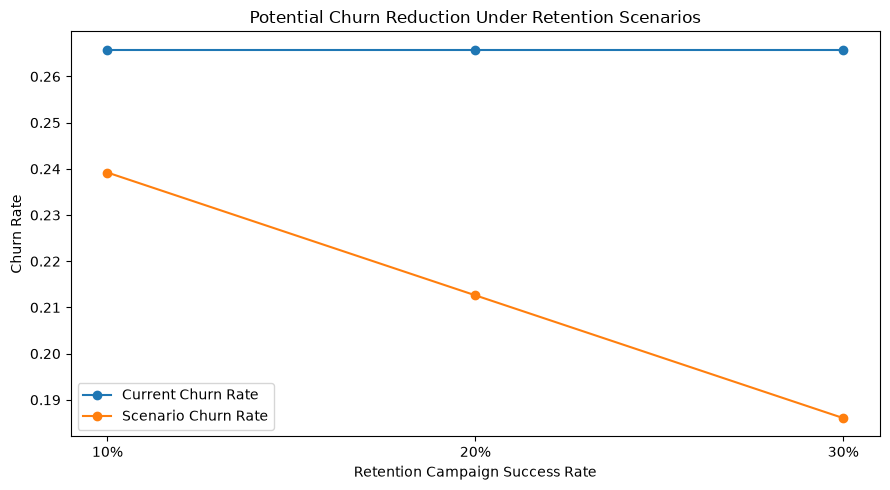

In [28]:
# Cell 28 — Visualize Potential Churn Impact

plt.figure(figsize=(9, 5))

labels = [
    f"{x:.0%}" for x in impact_df["Retention_Success_Rate"]
]

plt.plot(
    labels,
    [current_churn_rate] * len(labels),
    marker="o",
    label="Current Churn Rate"
)

plt.plot(
    labels,
    impact_df["Estimated_Churn_Rate"],
    marker="o",
    label="Scenario Churn Rate"
)

plt.xlabel("Retention Campaign Success Rate")
plt.ylabel("Churn Rate")
plt.title("Potential Churn Reduction Under Retention Scenarios")
plt.legend()

plt.tight_layout()
plt.show()


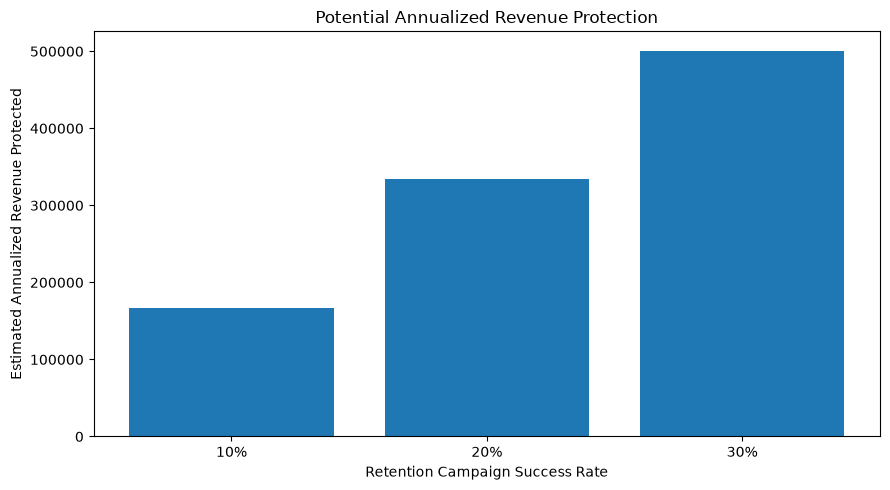

In [29]:
# Cell 29 — Visualize Potential Revenue Protection

plt.figure(figsize=(9, 5))

plt.bar(
    labels,
    impact_df["Estimated_Annualized_Revenue_Protected"]
)

plt.xlabel("Retention Campaign Success Rate")
plt.ylabel("Estimated Annualized Revenue Protected")
plt.title("Potential Annualized Revenue Protection")

plt.tight_layout()
plt.show()


In [30]:
# Cell 30 — Create High-Risk Customer Action List

def recommended_action(probability):

    if probability >= 0.75:
        return "Immediate retention contact + personalized offer"
    elif probability >= 0.60:
        return "Priority retention campaign + service engagement"
    elif probability >= 0.30:
        return "Targeted engagement and monitoring"
    else:
        return "Standard customer engagement"

customer_risk["Recommended_Action"] = (
    customer_risk["Churn_Probability"]
    .apply(recommended_action)
)

high_risk_customers = customer_risk[
    customer_risk["Risk_Level"] == "High Risk"
].copy()

high_risk_customers = high_risk_customers.sort_values(
    "Churn_Probability",
    ascending=False
)

print("High-risk customers:", len(high_risk_customers))

high_risk_customers[
    [
        "Churn_Probability",
        "Risk_Level",
        "Recommended_Action",
        "Contract",
        "InternetService",
        "MonthlyCharges",
        "TotalCharges",
        "tenure"
    ]
].head(20)


High-risk customers: 1019


,Churn_Probability,Risk_Level,Recommended_Action,Contract,InternetService,MonthlyCharges,TotalCharges,tenure
3374,0.845984,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,95.10,95.10,1
4792,0.845116,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,94.00,94.00,1
1971,0.844775,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,93.55,93.55,1
1405,0.843478,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,93.85,170.85,2
2203,0.843147,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,100.80,100.80,1
3743,0.841455,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,93.85,196.75,2
6359,0.840914,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,94.00,181.70,2
3154,0.840158,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,94.85,335.75,3
994,0.838701,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,94.30,424.45,4
301,0.838310,High Risk,Immediate retention contact + personalized offer,Month-to-month,Fiber optic,95.45,396.10,4


In [31]:
# Cell 31 — Business KPIs for Measuring Recommendations

business_kpis = pd.DataFrame({
    "KPI": [
        "Churn Rate",
        "Retention Rate",
        "Customers Saved",
        "Revenue Protected",
        "Retention Offer Conversion Rate",
        "Campaign Cost",
        "Net Revenue Impact",
        "Campaign ROI"
    ],
    "Purpose": [
        "Measure the percentage of customers leaving.",
        "Measure the percentage of customers retained.",
        "Measure the number of at-risk customers successfully retained.",
        "Estimate revenue preserved through successful retention.",
        "Measure the effectiveness of retention offers.",
        "Track the cost of retention activities.",
        "Compare financial benefit against campaign cost.",
        "Measure financial efficiency of retention campaigns."
    ]
})

business_kpis


,KPI,Purpose
0,Churn Rate,Measure the percentage of customers leaving.
1,Retention Rate,Measure the percentage of customers retained.
2,Customers Saved,Measure the number of at-risk customers succes...
3,Revenue Protected,Estimate revenue preserved through successful ...
4,Retention Offer Conversion Rate,Measure the effectiveness of retention offers.
5,Campaign Cost,Track the cost of retention activities.
6,Net Revenue Impact,Compare financial benefit against campaign cost.
7,Campaign ROI,Measure financial efficiency of retention camp...


In [32]:
# Cell 32 — Final Business Interpretation

print("=" * 85)
print("TASK 6 — FINAL BUSINESS INTERPRETATION")
print("=" * 85)

print(f"\nCurrent churn rate: {current_churn_rate:.2%}")

print(f"Total customers: {total_customers:,}")

print(f"Churned customers: {churned_customers:,}")

print(f"High-risk customers identified: {len(high_risk_customers):,}")

print(
    f"Best predictive model: {best_model_name}"
)

print(
    f"Highest-priority observed segment: "
    f"{highest_priority_segment['Segment_Type']} = "
    f"{highest_priority_segment['Segment_Value']}"
)

print(
    f"Priority segment observed churn rate: "
    f"{highest_priority_segment['Churn_Rate']:.2%}"
)

print("\nRecommended business approach:")

print(
    "1. Use the churn model to prioritize customers rather than treating "
    "all customers equally."
)

print(
    "2. Combine churn probability with revenue exposure when allocating "
    "retention resources."
)

print(
    "3. Use targeted contract, onboarding, service and payment interventions "
    "based on the observed customer segments."
)

print(
    "4. Test retention offers through controlled campaigns and measure "
    "customers saved, churn reduction, revenue protected and ROI."
)

print(
    "\nImportant limitation:"
)

print(
    "The model identifies statistical patterns associated with churn. "
    "It does not establish that any particular feature causes churn."
)


TASK 6 — FINAL BUSINESS INTERPRETATION

Current churn rate: 26.58%
Total customers: 7,032
Churned customers: 1,869
High-risk customers identified: 1,019
Best predictive model: Logistic Regression
Highest-priority observed segment: InternetService = Fiber optic
Priority segment observed churn rate: 41.89%

Recommended business approach:
1. Use the churn model to prioritize customers rather than treating all customers equally.
2. Combine churn probability with revenue exposure when allocating retention resources.
3. Use targeted contract, onboarding, service and payment interventions based on the observed customer segments.
4. Test retention offers through controlled campaigns and measure customers saved, churn reduction, revenue protected and ROI.

Important limitation:
The model identifies statistical patterns associated with churn. It does not establish that any particular feature causes churn.


In [33]:
# Cell 33 — Final Impact Interpretation

best_scenario = impact_df.iloc[-1]

print("=" * 85)
print("POTENTIAL IMPACT ESTIMATION")
print("=" * 85)

print(
    f"\nScenario retention success rate: "
    f"{best_scenario['Retention_Success_Rate']:.0%}"
)

print(
    f"Estimated customers saved: "
    f"{best_scenario['Estimated_Customers_Saved']:,.0f}"
)

print(
    f"Estimated churn rate after scenario: "
    f"{best_scenario['Estimated_Churn_Rate']:.2%}"
)

print(
    f"Estimated churn-rate reduction: "
    f"{best_scenario['Estimated_Churn_Rate_Reduction']:.2%}"
)

print(
    f"Estimated annualized revenue protected: "
    f"₹{best_scenario['Estimated_Annualized_Revenue_Protected']:,.2f}"
)

print(
    f"Estimated campaign cost: "
    f"₹{best_scenario['Estimated_Campaign_Cost']:,.2f}"
)

print(
    f"Estimated net revenue impact: "
    f"₹{best_scenario['Estimated_Net_Revenue_Impact']:,.2f}"
)

print(
    f"Estimated ROI: "
    f"{best_scenario['Estimated_ROI']:.2f}x"
)

print(
    "\nNote: These are scenario estimates based on explicit assumptions. "
    "They are not guaranteed outcomes and should be validated through "
    "actual retention campaigns or A/B testing."
)


POTENTIAL IMPACT ESTIMATION

Scenario retention success rate: 30%
Estimated customers saved: 561
Estimated churn rate after scenario: 18.60%
Estimated churn-rate reduction: 7.97%
Estimated annualized revenue protected: ₹500,871.06
Estimated campaign cost: ₹50,087.11
Estimated net revenue impact: ₹450,783.95
Estimated ROI: 9.00x

Note: These are scenario estimates based on explicit assumptions. They are not guaranteed outcomes and should be validated through actual retention campaigns or A/B testing.


In [34]:
# Cell 34 — Save Task 6 Outputs

output_folder = "Task_6_Outputs"
os.makedirs(output_folder, exist_ok=True)

business_baseline.to_csv(
    os.path.join(output_folder, "business_baseline.csv"),
    index=False
)

contract_analysis.to_csv(
    os.path.join(output_folder, "contract_churn_analysis.csv"),
    index=False
)

tenure_analysis.to_csv(
    os.path.join(output_folder, "tenure_churn_analysis.csv"),
    index=False
)

internet_analysis.to_csv(
    os.path.join(output_folder, "internet_service_churn_analysis.csv"),
    index=False
)

payment_analysis.to_csv(
    os.path.join(output_folder, "payment_method_churn_analysis.csv"),
    index=False
)

senior_analysis.to_csv(
    os.path.join(output_folder, "senior_citizen_churn_analysis.csv"),
    index=False
)

model_comparison.to_csv(
    os.path.join(output_folder, "model_comparison.csv"),
    index=False
)

risk_summary.to_csv(
    os.path.join(output_folder, "customer_risk_summary.csv"),
    index=False
)

priority_segments.to_csv(
    os.path.join(output_folder, "priority_segments.csv"),
    index=False
)

recommendations.to_csv(
    os.path.join(output_folder, "business_recommendations.csv"),
    index=False
)

impact_df.to_csv(
    os.path.join(output_folder, "business_impact_estimates.csv"),
    index=False
)

high_risk_customers.to_csv(
    os.path.join(output_folder, "high_risk_customer_actions.csv"),
    index=False
)

business_kpis.to_csv(
    os.path.join(output_folder, "business_kpis.csv"),
    index=False
)

final_metrics_df.to_csv(
    os.path.join(output_folder, "final_model_metrics.csv"),
    index=False
)

print("All Task 6 outputs saved to:", output_folder)


All Task 6 outputs saved to: Task_6_Outputs


In [35]:
# Cell 35 — Final Verification

print("=" * 85)
print("TASK 6 COMPLETED SUCCESSFULLY")
print("=" * 85)

print("\nDataset:", file_path)
print("Best Model:", best_model_name)
print(f"Current Churn Rate: {current_churn_rate:.2%}")
print(f"High-Risk Customers: {len(high_risk_customers):,}")
print(
    "Highest Priority Segment:",
    f"{highest_priority_segment['Segment_Type']} = "
    f"{highest_priority_segment['Segment_Value']}"
)
print("Output Folder:", output_folder)

print(
    "\nThe notebook provides data-driven recommendations, "
    "scenario-based churn impact estimates, revenue estimates, "
    "customer prioritization and business KPIs."
)


TASK 6 COMPLETED SUCCESSFULLY

Dataset: C:\Users\bts\OneDrive\Desktop\SaiKet Systems\dataset\Telco_Customer_Churn_Dataset.csv
Best Model: Logistic Regression
Current Churn Rate: 26.58%
High-Risk Customers: 1,019
Highest Priority Segment: InternetService = Fiber optic
Output Folder: Task_6_Outputs

The notebook provides data-driven recommendations, scenario-based churn impact estimates, revenue estimates, customer prioritization and business KPIs.
